# ES / NQ Correlation & Mean-Reversion Spread Study (Hourly, yfinance)

This notebook:
1. Loads **hourly** ES (`ES=F`) and NQ (`NQ=F`) futures history via `yfinance`, with MT5/CSV/synthetic fallbacks
2. Studies rolling/full-sample correlation between the two
3. Builds a **hedge-ratio-adjusted spread** (not a naive `ES - NQ`, which isn't meaningful given the different price scales)
4. Tests the spread for stationarity (ADF test) — a real mean-reversion strategy needs this
5. Runs a z-score based mean-reversion strategy on the spread
6. Backtests it and plots results

> **Note on yfinance + hourly data:** Yahoo Finance only serves `interval="1h"` data for roughly the trailing **730 days**, and continuous futures contracts (`ES=F`, `NQ=F`) are Yahoo's back-adjusted continuations, not the exact broker feed you'd trade on in MT5 — treat this as a solid research proxy, not a tick-perfect match to your execution venue.
>
> If `yfinance` can't reach the network (e.g. sandboxed environments), the loader below **automatically falls back to synthetic hourly data** so the rest of the notebook still runs end-to-end. Run this notebook somewhere with open internet access to pull the real data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm

pd.set_option("display.width", 140)
%matplotlib inline

In [2]:
SOURCE = "yfinance"           # "yfinance" | "mt5" | "csv" | "synthetic"

# --- yfinance settings (only used if SOURCE == "yfinance") ---
YF_ES_TICKER = "ES=F"         # CME E-mini S&P 500 continuous futures
YF_NQ_TICKER = "NQ=F"         # CME E-mini Nasdaq-100 continuous futures
YF_INTERVAL = "1h"            # hourly bars
YF_PERIOD = "730d"            # yfinance's max lookback for 1h interval

# --- mt5 settings (only used if SOURCE == "mt5") ---
MT5_TIMEFRAME = "H1"
MT5_BARS = 20000
MT5_ES_SYMBOL = "ES"          # adjust to your broker's exact symbol, e.g. "US500.f"
MT5_NQ_SYMBOL = "NQ"          # e.g. "USTEC.f"

# --- csv settings (only used if SOURCE == "csv") ---
ES_CSV_PATH = "ES.csv"        # columns: time, open, high, low, close
NQ_CSV_PATH = "NQ.csv"

# --- strategy / study params (in HOURS, since bars are hourly) ---
CORR_WINDOW = 120             # ~5 trading days of hourly bars
BETA_WINDOW = 480             # ~20 trading days
Z_WINDOW = 120                # ~5 trading days
ENTRY_Z = 2.0
EXIT_Z = 0.5
STOP_Z = 4.0
COST_PER_TRADE = 0.5          # in spread points, round-trip friction/slippage

## 2. Data loading

In [3]:
def load_from_yfinance(es_ticker: str, nq_ticker: str, interval: str, period: str) -> pd.DataFrame:
    """Pull hourly ES/NQ continuous-futures bars from Yahoo Finance via yfinance.
    Falls back to synthetic hourly data if the network/API call fails (e.g. in a
    sandboxed environment without internet access) so the notebook still runs.
    """
    import yfinance as yf

    try:
        es = yf.download(es_ticker, period=period, interval=interval,
                          progress=False, auto_adjust=True)
        nq = yf.download(nq_ticker, period=period, interval=interval,
                          progress=False, auto_adjust=True)

        if es is None or nq is None or es.empty or nq.empty:
            raise RuntimeError("yfinance returned empty data")

        # yfinance can return either flat or MultiIndex columns depending on version
        es_close = es["Close"] if "Close" in es.columns else es[("Close", es_ticker)]
        nq_close = nq["Close"] if "Close" in nq.columns else nq[("Close", nq_ticker)]

        out = pd.DataFrame({"ES": es_close.squeeze(), "NQ": nq_close.squeeze()}).dropna()
        if out.empty:
            raise RuntimeError("no overlapping ES/NQ timestamps after join")

        print(f"Loaded {len(out)} hourly bars from yfinance "
              f"({out.index.min()} -> {out.index.max()})")
        return out

    except Exception as e:
        print(f"yfinance fetch failed ({e!r}). Falling back to synthetic hourly data. "
              f"Run this notebook with internet access to get the real feed.")
        return load_synthetic(freq="h")


def load_from_mt5(timeframe: str, bars: int, es_symbol: str, nq_symbol: str) -> pd.DataFrame:
    """Pull ES / NQ bars from a running MetaTrader5 terminal.
    Requires: pip install MetaTrader5   (Windows, or Wine on Linux/Mac)
    """
    import MetaTrader5 as mt5

    if not mt5.initialize():
        raise RuntimeError(f"MT5 initialize() failed: {mt5.last_error()}")

    tf_map = {
        "M1": mt5.TIMEFRAME_M1, "M5": mt5.TIMEFRAME_M5, "M15": mt5.TIMEFRAME_M15,
        "M30": mt5.TIMEFRAME_M30, "H1": mt5.TIMEFRAME_H1, "H4": mt5.TIMEFRAME_H4,
        "D1": mt5.TIMEFRAME_D1,
    }
    tf = tf_map[timeframe]

    def _pull(symbol):
        if not mt5.symbol_select(symbol, True):
            raise RuntimeError(f"Could not select symbol {symbol}. Check exact name in Market Watch.")
        rates = mt5.copy_rates_from_pos(symbol, tf, 0, bars)
        if rates is None or len(rates) == 0:
            raise RuntimeError(f"No data returned for {symbol}")
        df = pd.DataFrame(rates)
        df["time"] = pd.to_datetime(df["time"], unit="s")
        return df.set_index("time")[["close"]].rename(columns={"close": symbol})

    es = _pull(es_symbol)
    nq = _pull(nq_symbol)
    mt5.shutdown()

    out = es.join(nq, how="inner")
    out.columns = ["ES", "NQ"]
    return out


def load_from_csv(es_csv: str, nq_csv: str) -> pd.DataFrame:
    es = pd.read_csv(es_csv, parse_dates=["time"]).set_index("time")[["close"]]
    nq = pd.read_csv(nq_csv, parse_dates=["time"]).set_index("time")[["close"]]
    out = es.join(nq, how="inner", lsuffix="_ES", rsuffix="_NQ")
    out.columns = ["ES", "NQ"]
    return out


def load_synthetic(n=4000, seed=42, freq="h") -> pd.DataFrame:
    """Two cointegrated series that loosely resemble ES/NQ: a shared random-walk
    factor plus idiosyncratic mean-reverting noise. Demo purposes only.
    freq="h" -> hourly bars (matches the real yfinance/MT5 H1 data this notebook
    is set up for)."""
    rng = np.random.default_rng(seed)
    dt = pd.bdate_range("2022-01-01", periods=n, freq=freq)

    common_factor = np.cumsum(rng.normal(0, 1, n))
    idio_es = np.cumsum(rng.normal(0, 0.15, n))
    idio_nq = np.cumsum(rng.normal(0, 0.15, n))

    mr = np.zeros(n)
    for i in range(1, n):
        mr[i] = 0.995 * mr[i - 1] + rng.normal(0, 0.05)

    beta_true = 3.6
    es_price = 4500 + common_factor * 1.0 + idio_es
    nq_price = 15500 + common_factor * beta_true + idio_nq * beta_true + mr * 5

    return pd.DataFrame({"ES": es_price, "NQ": nq_price}, index=dt)


if SOURCE == "yfinance":
    df = load_from_yfinance(YF_ES_TICKER, YF_NQ_TICKER, YF_INTERVAL, YF_PERIOD)
elif SOURCE == "mt5":
    df = load_from_mt5(MT5_TIMEFRAME, MT5_BARS, MT5_ES_SYMBOL, MT5_NQ_SYMBOL)
elif SOURCE == "csv":
    df = load_from_csv(ES_CSV_PATH, NQ_CSV_PATH)
else:
    print("Using synthetic demo hourly data. Set SOURCE = \"yfinance\", \"mt5\" or \"csv\" for a real study.")
    df = load_synthetic(freq="h")

df.tail()

Loaded 13708 hourly bars from yfinance (2024-03-17 18:00:00-04:00 -> 2026-08-07 16:00:00-04:00)


,ES,NQ
Datetime,,
2026-08-07 12:00:00-04:00,7767.00,29739.50
2026-08-07 13:00:00-04:00,7768.75,29743.25
2026-08-07 14:00:00-04:00,7764.50,29725.00
2026-08-07 15:00:00-04:00,7778.50,29834.25
2026-08-07 16:00:00-04:00,7779.75,29834.75


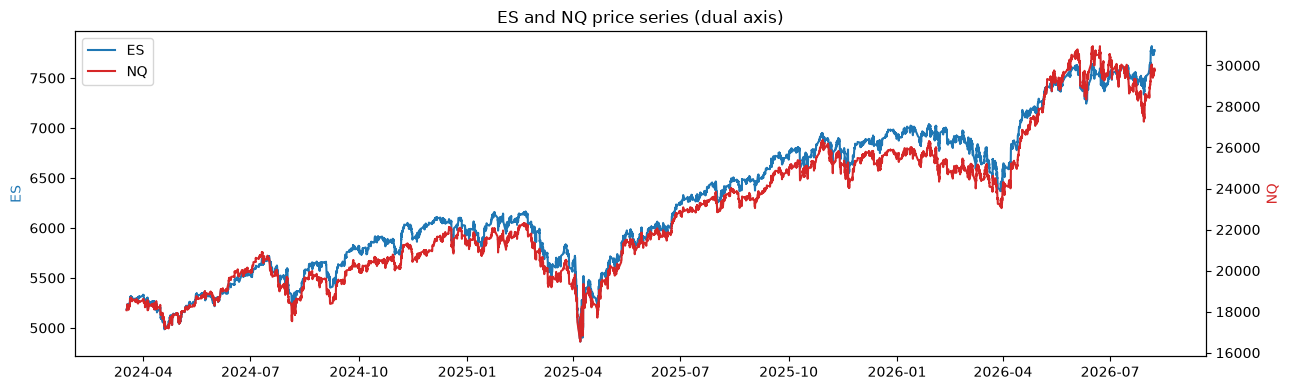

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
ax2 = ax.twinx()
ax.plot(df.index, df["ES"], color="#1f77b4", label="ES")
ax2.plot(df.index, df["NQ"], color="#d62728", label="NQ")
ax.set_ylabel("ES", color="#1f77b4")
ax2.set_ylabel("NQ", color="#d62728")
ax.set_title("ES and NQ price series (dual axis)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Correlation study

ES and NQ returns are typically highly correlated (both are US equity index futures driven by the same macro/rates factors), but the correlation isn't constant — it compresses or breaks during sector rotations (e.g. mega-cap tech vs broad market divergence).

Full-sample return correlation (ES vs NQ): 0.9290
Rolling 120-bar correlation: mean=0.9204, min=-0.1150, max=0.9943


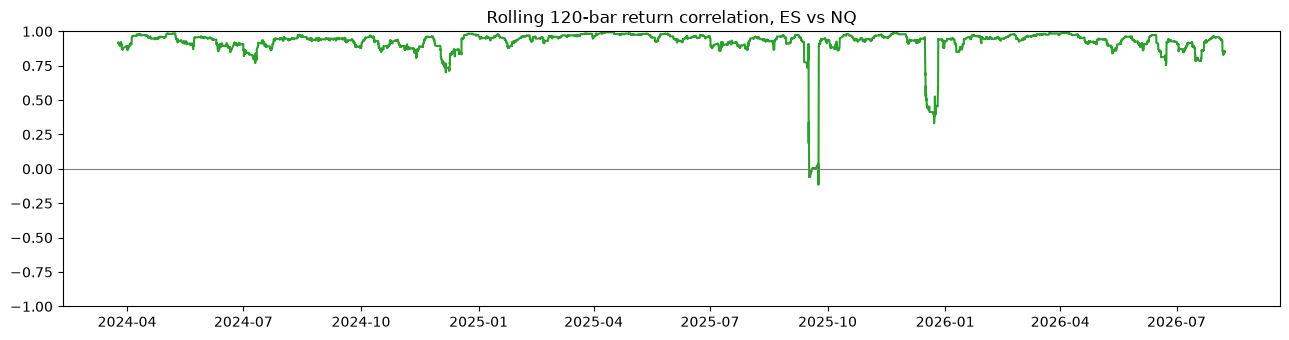

In [5]:
rets = df.pct_change().dropna()
full_corr = rets["ES"].corr(rets["NQ"])
rolling_corr = rets["ES"].rolling(CORR_WINDOW).corr(rets["NQ"])

print(f"Full-sample return correlation (ES vs NQ): {full_corr:.4f}")
print(f"Rolling {CORR_WINDOW}-bar correlation: mean={rolling_corr.mean():.4f}, "
      f"min={rolling_corr.min():.4f}, max={rolling_corr.max():.4f}")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(rolling_corr.index, rolling_corr.values, color="#2ca02c")
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylim(-1, 1)
ax.set_title(f"Rolling {CORR_WINDOW}-bar return correlation, ES vs NQ")
plt.tight_layout()
plt.show()

## 4. Hedge-ratio-adjusted spread

Raw `ES - NQ` is **not** a valid mean-reversion spread: NQ trades at a much higher price level and different volatility than ES, so a naive difference just tracks whichever leg has the bigger notional swings — it won't mean-revert around a stable level.

Instead, estimate a rolling hedge ratio (beta) via OLS:

```
ES_t = alpha + beta * NQ_t + spread_t
```

and treat `spread_t` as the mean-reverting quantity. Beta is refit on a rolling window so it adapts to slow drift in the relationship (e.g. tech's growing weight in the S&P 500 pulls ES and NQ closer over time).

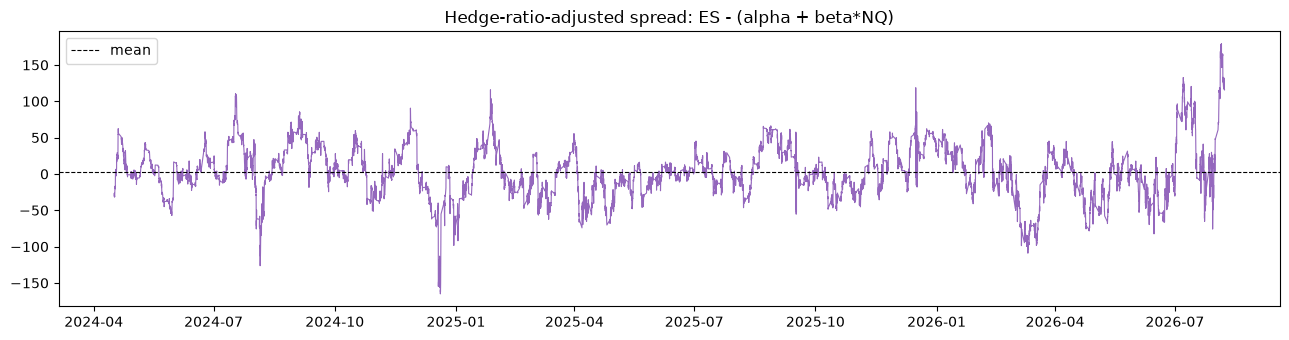

In [6]:
y = df["ES"]
X = sm.add_constant(df["NQ"])
rolling_model = RollingOLS(y, X, window=BETA_WINDOW)
fit = rolling_model.fit()

beta = fit.params["NQ"]
alpha = fit.params["const"]
spread = (df["ES"] - (alpha + beta * df["NQ"])).dropna()
beta = beta.reindex(spread.index)

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(spread.index, spread.values, color="#9467bd", lw=0.8)
ax.axhline(spread.mean(), color="black", lw=0.8, ls="--", label="mean")
ax.set_title("Hedge-ratio-adjusted spread: ES - (alpha + beta*NQ)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Stationarity test (ADF)

A real mean-reversion strategy needs the spread to be statistically stationary — not just "look like" it reverts on a chart.

In [7]:
result = adfuller(spread.dropna(), autolag="AIC")
stat, pvalue, lags, nobs, crit_values, _ = result

print(f"ADF statistic: {stat:.4f}")
print(f"p-value:       {pvalue:.4f}")
print("Critical values:", {k: round(v, 3) for k, v in crit_values.items()})

if pvalue < 0.05:
    print("=> Spread appears stationary (mean-reverting) at 5% significance.")
else:
    print("=> Spread does NOT reject the unit-root null -- mean reversion is not "
          "statistically supported on this sample. Don't trade a non-stationary spread.")

ADF statistic: -6.4598
p-value:       0.0000
Critical values: {'1%': np.float64(-3.431), '5%': np.float64(-2.862), '10%': np.float64(-2.567)}
=> Spread appears stationary (mean-reverting) at 5% significance.


## 6. Mean-reversion strategy

Rules (classic pairs-trading / stat-arb):
- `z` = rolling z-score of the spread
- `z > +ENTRY_Z` → spread is rich: **short** the spread (short ES, long NQ×beta)
- `z < -ENTRY_Z` → spread is cheap: **long** the spread (long ES, short NQ×beta)
- `|z| < EXIT_Z` → flatten (reverted to mean)
- `|z| > STOP_Z` → hard stop (relationship may have broken down)

In [8]:
def zscore(series, window):
    m = series.rolling(window).mean()
    s = series.rolling(window).std()
    return (series - m) / s

z = zscore(spread, Z_WINDOW)
bt = pd.DataFrame({"spread": spread, "beta": beta, "z": z}).dropna()

position = np.zeros(len(bt))
pos = 0
for i in range(1, len(bt)):
    zi = bt["z"].iloc[i]
    if pos == 0:
        if zi > ENTRY_Z:
            pos = -1
        elif zi < -ENTRY_Z:
            pos = 1
    else:
        if abs(zi) < EXIT_Z or abs(zi) > STOP_Z:
            pos = 0
    position[i] = pos

bt["position"] = position
bt["spread_change"] = bt["spread"].diff().fillna(0)
bt["raw_pnl"] = bt["position"].shift(1).fillna(0) * bt["spread_change"]

trade_change = bt["position"].diff().fillna(bt["position"]).abs()
bt["costs"] = trade_change * COST_PER_TRADE
bt["pnl"] = bt["raw_pnl"] - bt["costs"]
bt["equity"] = bt["pnl"].cumsum()

bt.tail()

,spread,beta,z,position,spread_change,raw_pnl,costs,pnl,equity
Datetime,,,,,,,,,
2026-08-07 12:00:00-04:00,118.590805,0.121967,-0.098938,0.0,-2.910053,-0.0,0.0,-0.0,487.370078
2026-08-07 13:00:00-04:00,118.921804,0.122706,-0.116727,0.0,0.330999,0.0,0.0,0.0,487.370078
2026-08-07 14:00:00-04:00,115.986648,0.123421,-0.218448,0.0,-2.935156,-0.0,0.0,-0.0,487.370078
2026-08-07 15:00:00-04:00,115.448133,0.124200,-0.262065,0.0,-0.538515,-0.0,0.0,-0.0,487.370078
2026-08-07 16:00:00-04:00,115.596945,0.124956,-0.287531,0.0,0.148812,0.0,0.0,0.0,487.370078


## 7. Backtest stats

In [9]:
n_trades = int((trade_change > 0).sum())
total_pnl = bt["pnl"].sum()
daily_like = bt["pnl"][bt["pnl"] != 0]
sharpe = (np.sqrt(252) * daily_like.mean() / daily_like.std()
          if len(daily_like) > 1 and daily_like.std() > 0 else float("nan"))
running_max = bt["equity"].cummax()
drawdown = bt["equity"] - running_max
max_dd = drawdown.min()

trade_pnls, cur, in_trade = [], 0.0, False
for i in range(len(bt)):
    if bt["position"].iloc[i] != 0:
        in_trade = True
        cur += bt["pnl"].iloc[i]
    else:
        if in_trade:
            trade_pnls.append(cur)
            cur = 0.0
            in_trade = False
if in_trade:
    trade_pnls.append(cur)
trade_pnls = np.array(trade_pnls)
win_rate = (trade_pnls > 0).mean() if len(trade_pnls) else float("nan")

print(f"Number of round-trip trades: {n_trades}")
print(f"Total PnL (spread pts):      {total_pnl:.2f}")
print(f"Annualized Sharpe (approx):  {sharpe:.2f}")
print(f"Max drawdown (spread pts):   {max_dd:.2f}")
print(f"Win rate:                    {win_rate:.1%}" if len(trade_pnls) else "Win rate: n/a")
print("\nTo convert to $, multiply ES pts by $50/pt and NQ pts by $20/pt (CME e-mini "
      "multipliers; $5/$2 for the Micro versions) -- the two legs have different point "
      "values, so position sizing must weight contracts by (multiplier x beta), not beta alone.")

Number of round-trip trades: 278
Total PnL (spread pts):      487.37
Annualized Sharpe (approx):  0.23
Max drawdown (spread pts):   -152.44
Win rate:                    56.1%

To convert to $, multiply ES pts by $50/pt and NQ pts by $20/pt (CME e-mini multipliers; $5/$2 for the Micro versions) -- the two legs have different point values, so position sizing must weight contracts by (multiplier x beta), not beta alone.


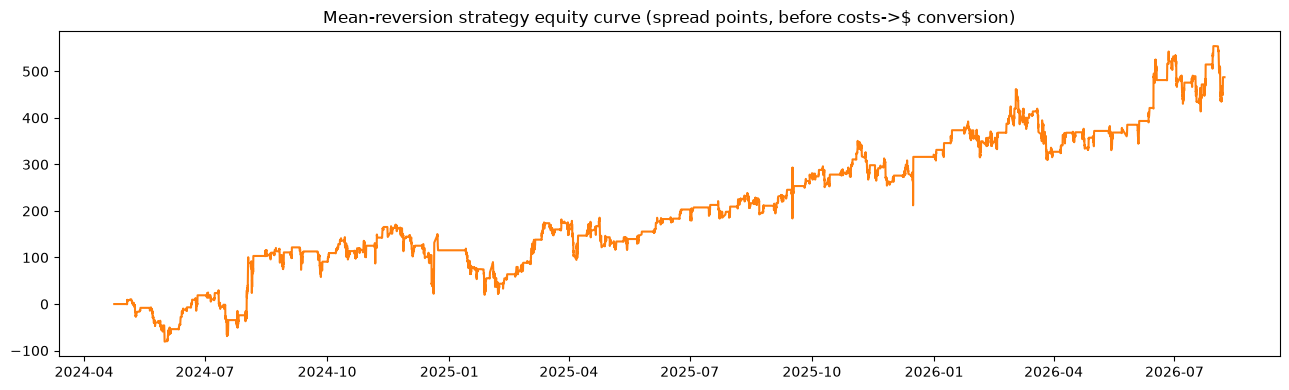

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(bt.index, bt["equity"], color="#ff7f0e")
ax.set_title("Mean-reversion strategy equity curve (spread points, before costs->$ conversion)")
plt.tight_layout()
plt.show()

## Notes / next steps

- **Run this notebook with internet access** for `SOURCE = "yfinance"` to actually pull real ES/NQ hourly bars — this sandbox blocked the Yahoo Finance hosts, so the run above used the synthetic fallback.
- `yfinance`'s 1h interval only goes back ~730 days and uses Yahoo's back-adjusted continuous contracts — good for research, not identical to your broker's raw feed. For execution-grade data, switch `SOURCE` to `"mt5"` (set the exact broker symbol names, often suffixed like `US500.f` / `USTEC.f`) — a natural fit since you're already pulling MT5 data for `HotkeyTrader.mq5`.
- Re-run the ADF test whenever you change the data window; stationarity isn't guaranteed to hold across all regimes.
- `ENTRY_Z` / `EXIT_Z` / `STOP_Z` and `BETA_WINDOW` / `Z_WINDOW` are the main levers to walk-forward test — the defaults here (in hours) aren't tuned, just illustrative.
- Position sizing for real capital needs `contracts_NQ = beta * (ES_multiplier / NQ_multiplier) * contracts_ES`.